In [1]:
#Spam Detection Model using CNN and ANN 
import tensorflow as tf
tf.__version__

'2.16.1'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
data = pd.read_csv('SMSSpamCollection', sep="\t", names = ['label_old','message'])

In [4]:
data.head()

,label_old,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label_old  5572 non-null   object
 1   message    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
#Binarize labels
data['label']=data['label_old'].map({'ham':0, 'spam':1})
data.head()

,label_old,message,label
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [7]:
#Seperate data as features and label
features = data.message.values
label = data.label.values

In [8]:
features[0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [9]:
#Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(features,
                                                 label,
                                                 test_size=0.2,
                                                 random_state = 1)

In [10]:
y_train

array([0, 0, 0, ..., 0, 1, 0])

In [11]:
X_train[0]

"Hi , where are you? We're at  and they're not keen to go out i kind of am but feel i shouldn't so can we go out tomo, don't mind do you?"

In [12]:
# For Tokenization
from tensorflow.keras.preprocessing.text import Tokenizer

#Decide the Vocabulary Word Frequency Size

vocabFreqWordSize = None

# If the word 'spiderman' exists a minimum of num_words times in the corpus,
# then it will be added in the vocab dictionary

#Convert the sentences into sequence of words

tokenizer = Tokenizer(num_words=vocabFreqWordSize)

#Fit the training data

tokenizer.fit_on_texts(X_train)




In [13]:
#Lets create the sequence objects

seq_train = tokenizer.texts_to_sequences(X_train)
seq_test = tokenizer.texts_to_sequences(X_test)

In [14]:
seq_test[0]

[1022, 72, 5, 788]

In [15]:
len(seq_train[3])

34

In [16]:
len(seq_train)

4457

In [17]:
#Lets pad the sequence data
#This creates a matrix where the
# rows = Documents
# Cols = Time Steps (For our understanding its the vocab with padding)

from tensorflow.keras.preprocessing.sequence import pad_sequences

trainData = pad_sequences(seq_train)
T = trainData.shape[1]
T

189

In [18]:
testData = pad_sequences(seq_test , maxlen=T)
testData.shape

(1115, 189)

In [19]:
len(trainData), len(testData)

(4457, 1115)

In [20]:
#Build the Model
#Question: Can we use ANN?
#Answer: We can use ANN if the dataset is small. BUt preferred is CNN due to data size and avoiding memory overflow issue
# and without compromising the quality of the data.

In [21]:
#Get the Vocab Size of the Tokenizer
V = len(tokenizer.word_index)

In [22]:
#CNN for Text data -- Conv1D



from tensorflow.keras.layers import Dense,Input,Conv1D,Embedding,MaxPooling1D,GlobalMaxPooling1D
from tensorflow.keras.models import Model

# 1. Create/Convert Seq data into Word Embedding / Embedded Data

#Input layer -  It takes in sequence of Integers i.e. T  (time step size ////// vocab size)

i = Input(shape=(T,))

#Create WordEmbedding ---- This layer will take sequence of integers and return sequence of word vectors
# Ideally input size is No of Docs X Time Steps
# When creating word embedding the dimension of matrix will be (Total_Vocabulary_Size + 1,Embedding Dim)
# Reason for + 1 is indexing of embedding starts from 1 and not 0


#You can decide the Embedding Dimensionality -- Hyperparameter
#Prashant Recommend ----> 10 to 100
D = 20

x = Embedding(V + 1,D)(i)

#First Convolution Layer

x = Conv1D(32,3,activation='relu')(x)
x = MaxPooling1D(3)(x)

#Second Convolution Layer

x = Conv1D(64,3,activation='relu')(x)
x = MaxPooling1D(3)(x)

#Third Convolution Layer

x = Conv1D(128,3,activation='relu')(x)
#x = Flatten()(x)
x = GlobalMaxPooling1D()(x)

#Dense Layer -- Output Layer

x = Dense(1,activation='sigmoid')(x)


model1 = Model(i,x)


2024-09-12 20:24:13.627477: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2024-09-12 20:24:13.627609: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2024-09-12 20:24:13.627634: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2024-09-12 20:24:13.627951: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-09-12 20:24:13.628084: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [23]:
#Compile
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [49]:
# model summary
model1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 189)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 189, 20)        │       159,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 187, 32)        │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 18, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577,121 (2.20 MB)

 Trainable params: 192,373 (751.46 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 384,748 (1.47 MB)

In [24]:
#Train
history1 = model1.fit(trainData,y_train, epochs=5, validation_data=(testData,y_test))

Epoch 1/5


2024-09-12 20:24:14.459509: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.8608 - loss: 0.4335 - val_accuracy: 0.9659 - val_loss: 0.1177
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9738 - loss: 0.0902 - val_accuracy: 0.9830 - val_loss: 0.0551
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9913 - loss: 0.0250 - val_accuracy: 0.9874 - val_loss: 0.0379
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9980 - loss: 0.0066 - val_accuracy: 0.9892 - val_loss: 0.0315
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9991 - loss: 0.0036 - val_accuracy: 0.9910 - val_loss: 0.0303


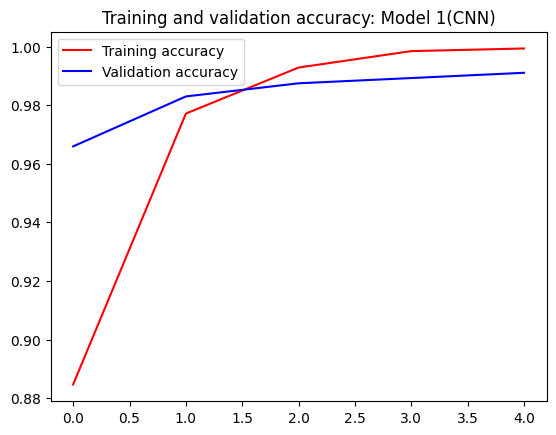

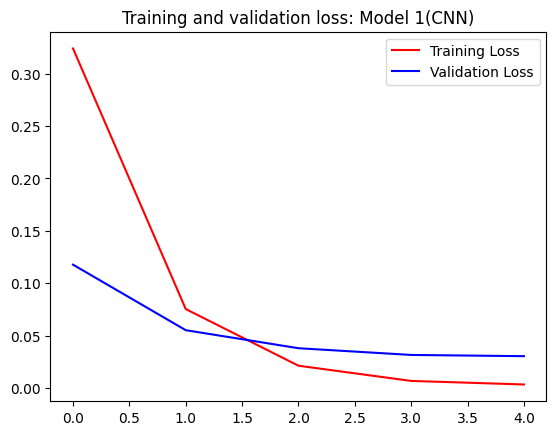

In [25]:
# plotting accuracy/loss
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy: Model 1(CNN)')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss: Model 1(CNN)')
plt.legend()

plt.show()


In [26]:
y_test[16]

1

In [27]:
classes = ["ham", "spam"]
SENTIMENT_THRESHOLDS = (0.4, 0.7)

text = X_test[16]
seq_tst = tokenizer.texts_to_sequences([text])
seq_pad = pad_sequences(seq_tst,maxlen=T)


y_prob = model1.predict(seq_pad)[0]



    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


In [28]:
# SENTIMENT
import time
SPAM = "SPAM"
HAM = "HAM"
NEUTRAL = "NEUTRAL"
SENTIMENT_THRESHOLDS = (0.4, 0.7)


In [29]:
def decode_sentiment(score, include_neutral=True):
    if include_neutral:        
        label = NEUTRAL
        if score <= SENTIMENT_THRESHOLDS[0]:
            label = 'HAM'
        elif score >= SENTIMENT_THRESHOLDS[1]:
            label = 'SPAM'

        return label
    else:
        return HAM if score < 0.5 else SPAM


In [30]:
def predict(model,text, include_neutral=True):
    start_at = time.time()
    # Tokenize text
    x_test = pad_sequences(tokenizer.texts_to_sequences([text]), maxlen=T)
    # Predict
    score = model.predict([x_test])[0]
    # Decode sentiment
    label = decode_sentiment(score, include_neutral=include_neutral)

    return {"label": label, "score": float(score),
       "elapsed_time": time.time()-start_at}  


In [31]:
X_test[12]

'Ok which your another number'

In [32]:
predict(model1, X_test[12])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


/var/folders/gz/2r04fdmd399crns3_hfqs3lw0000gn/T/ipykernel_50549/3815967480.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return {"label": label, "score": float(score),


{'label': 'HAM',
 'score': 2.4160719476640224e-05,
 'elapsed_time': 0.1816849708557129}

In [33]:
predict(model1, "ok, I will be with you in 5 min. see you then")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/var/folders/gz/2r04fdmd399crns3_hfqs3lw0000gn/T/ipykernel_50549/3815967480.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return {"label": label, "score": float(score),


{'label': 'HAM',
 'score': 9.48675733525306e-05,
 'elapsed_time': 0.08413290977478027}

In [34]:
predict(model1,'win 1000 cash free of charge promo hot deal sexy')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/var/folders/gz/2r04fdmd399crns3_hfqs3lw0000gn/T/ipykernel_50549/3815967480.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return {"label": label, "score": float(score),


{'label': 'SPAM',
 'score': 0.9864258766174316,
 'elapsed_time': 0.03183102607727051}

In [35]:
# ANN Model Approach Code Style

In [36]:
from tensorflow.keras.layers import Dense,Input,Conv1D,Embedding,MaxPooling1D
from tensorflow.keras.layers import GlobalAvgPool1D, Dropout, GlobalMaxPool1D
from tensorflow.keras.models import Sequential

max_len=T #no of cols in the pad_seq of train data
embedding_dim=20 #hyperparameter
vocab_size=len(tokenizer.word_index) #trained tokenizer object word index

model2 = Sequential()
model2.add(Embedding(vocab_size, embedding_dim, input_length=max_len))
model2.add(Conv1D(128, 5, activation='relu'))
model2.add(GlobalMaxPool1D())
model2.add(Dense(24, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(1, activation='sigmoid'))

#Compile


#Fit



/Users/shanpadhi/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [47]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 189, 20)        │       159,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 185, 128)       │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 526,229 (2.01 MB)

 Trainable params: 175,409 (685.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 350,820 (1.34 MB)

In [38]:
#Custom Callback for early stopping

class MyThresholdCallBack(tf.keras.callbacks.Callback):
    def __init__(self,cl):
        super(MyThresholdCallBack, self).__init__()
        self.cl = cl

    def on_epoch_end(self, epoch, logs=None):
        test_score = logs["val_accuracy"]
        train_score = logs["accuracy"]

        if test_score > train_score and test_score > self.cl:
        #if test_score > self.cl:
            self.model.stop_training = True

In [39]:
myR2ScoreMonitor = MyThresholdCallBack(cl=0.70)

In [40]:
#Compile
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [41]:
#Train
history2 = model2.fit(trainData,y_train, epochs=10, validation_data=(testData,y_test))  #,callbacks=[myR2ScoreMonitor])

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8709 - loss: 0.4474 - val_accuracy: 0.9758 - val_loss: 0.1352
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9618 - loss: 0.1136 - val_accuracy: 0.9874 - val_loss: 0.0450
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9957 - loss: 0.0338 - val_accuracy: 0.9928 - val_loss: 0.0329
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9968 - loss: 0.0284 - val_accuracy: 0.9910 - val_loss: 0.0319
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9992 - loss: 0.0251 - val_accuracy: 0.9928 - val_loss: 0.0349
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9987 - loss: 0.0189 - val_accuracy: 0.9892 - val_loss: 0.0357
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9999 - loss: 0.0140 - val_accuracy: 0.9892 - val_loss: 0.0371
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9995 - loss: 0.0139 - val_accu

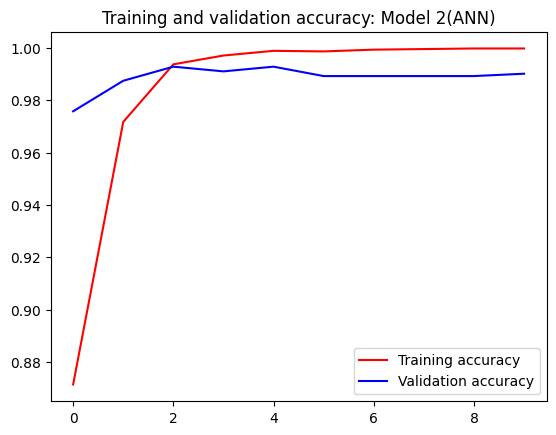

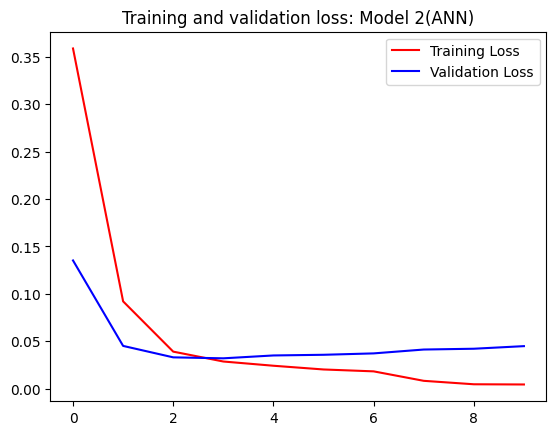

In [42]:

# plotting accuracy/loss
acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']
loss = history2.history['loss']
val_loss = history2.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy: Model 2(ANN)')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss: Model 2(ANN)')
plt.legend()

plt.show()

In [43]:
# model 2 prediction

predict(model2, X_test[12])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


/var/folders/gz/2r04fdmd399crns3_hfqs3lw0000gn/T/ipykernel_50549/3815967480.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return {"label": label, "score": float(score),


{'label': 'HAM',
 'score': 9.813732759766935e-08,
 'elapsed_time': 0.16705989837646484}

In [44]:
predict(model2, "ok, I will be with you in 5 min. see you then")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/var/folders/gz/2r04fdmd399crns3_hfqs3lw0000gn/T/ipykernel_50549/3815967480.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return {"label": label, "score": float(score),


{'label': 'HAM',
 'score': 5.474459108256724e-09,
 'elapsed_time': 0.08109521865844727}

In [45]:
predict(model2,'win 1000 cash free of charge promo hot deal sexy')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/var/folders/gz/2r04fdmd399crns3_hfqs3lw0000gn/T/ipykernel_50549/3815967480.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return {"label": label, "score": float(score),


{'label': 'SPAM',
 'score': 0.9967806339263916,
 'elapsed_time': 0.03129100799560547}

In [46]:
#Create Deployment code of User Input in Jupyter Notebook --